In [1]:
%pip install evaluate  datasets
%pip install sacremoses

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 848.8 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForMaskedLM,
    pipeline
)
from evaluate import load as load_metric

2025-07-07 14:05:17.570631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751897117.742119    2667 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751897117.916877    2667 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751897118.409514    2667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751897118.409621    2667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751897118.409625    2667 computation_placer.cc:177] computation placer alr

In [3]:
# Set up seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [5]:
foundation_model_name = "t5-large"  # Simple and well-known foundation model
domain_models = {
    "finance": ["yiyanghkust/finbert-tone"],
    "healthcare": ["d4data/biomedical-ner-all"],
    "legal": ["zlucia/legalbert"],
    "education": ["flax-community/roberta-base-edu"],
    "ecommerce": ["mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis"],
    "sports": ["mrm8488/bert-tiny-finetuned-sports-news-category"]
}


In [6]:
# Select your domain
selected_domain = "legal"

models_to_compare = [foundation_model_name] + domain_models[selected_domain]
tokenizers = {}
models = {}

for model_name in models_to_compare:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    try:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    except:
        model = AutoModelForMaskedLM.from_pretrained(model_name)
    tokenizers[model_name] = tokenizer
    models[model_name] = model

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/740 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

In [7]:
# -----------------------------
# Dataset and Preprocessing
# -----------------------------

sample_texts = [
    "The defendant was found guilty of breach of contract under section 73 of the Indian Contract Act.",
    "The court granted an injunction restraining the respondent from encroaching on the plaintiff's property.",
    "A writ petition was filed challenging the constitutional validity of the new tax legislation.",
    "The parties entered into an arbitration agreement to resolve their commercial disputes.",
    "The Supreme Court upheld the right to privacy as a fundamental right under Article 21.",
    "The accused was acquitted due to lack of evidence beyond reasonable doubt.",
    "The lease agreement was terminated for non-payment of rent as per the terms of the contract.",
    "The High Court directed the government to implement measures for environmental protection.",
    "A public interest litigation was filed seeking regulation of digital data privacy.",
    "The appellate court reversed the lower court's decision citing procedural irregularities.",
    "The contract contained a force majeure clause covering natural disasters and pandemics.",
    "The witness testimony was recorded via video conferencing as permitted by law."
]

def preprocess(text, tokenizer, max_length=128):
    return tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=max_length)


In [10]:

rouge = load_metric("rouge")
bleu = load_metric("bleu")

results = {}

for model_name in models_to_compare:
    model = models[model_name].eval()
    tokenizer = tokenizers[model_name]
    print(f"\nEvaluating {model_name}...")

    generated_texts = []
    for text in sample_texts:
        inputs = preprocess(text, tokenizer)
        with torch.no_grad():
            # Only use generate for models that support it (e.g., Seq2Seq or CausalLM)
            if hasattr(model, "generate") and callable(getattr(model, "generate", None)) and model.__class__.__name__.endswith(("ForConditionalGeneration", "ForCausalLM")):
                output = model.generate(**inputs)
                decoded = tokenizer.decode(output[0], skip_special_tokens=True)
            else:
                output = model(**inputs)
                token_ids = torch.argmax(output.logits, dim=-1)
                decoded = tokenizer.decode(token_ids[0], skip_special_tokens=True)
        generated_texts.append(decoded)

    # Compute BLEU and ROUGE-L
    bleu_score = bleu.compute(predictions=generated_texts,
                              references=sample_texts)
    rouge_score = rouge.compute(predictions=generated_texts, references=sample_texts)

    results[model_name] = {
        "BLEU": bleu_score["bleu"],
        "ROUGE-L": rouge_score["rougeL"] # Access rougeL directly
    }


Evaluating t5-large...

Evaluating zlucia/legalbert...


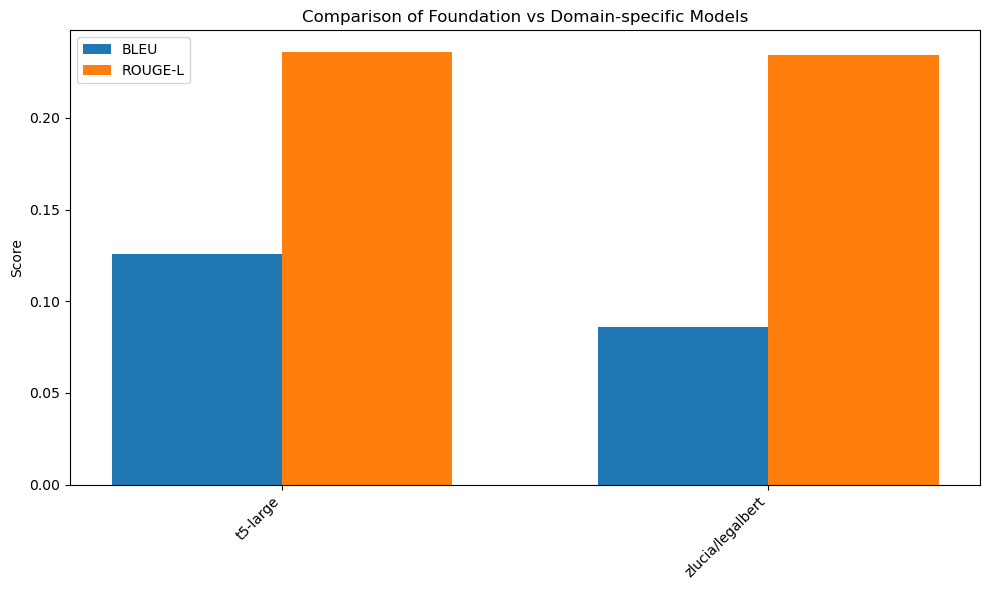

In [11]:
labels = list(results.keys())
bleu_scores = [results[m]["BLEU"] for m in labels]
rouge_scores = [results[m]["ROUGE-L"] for m in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, bleu_scores, width, label='BLEU')
plt.bar(x + width/2, rouge_scores, width, label='ROUGE-L')

plt.ylabel('Score')
plt.title('Comparison of Foundation vs Domain-specific Models')
plt.xticks(ticks=x, labels=labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:

domain_texts = {
    "finance": [
        "The central bank raised interest rates to control inflation.",
        "Quarterly earnings reports showed a decline in net profit.",
        "The merger of the two banks is expected to improve liquidity."
    ],
    "legal": [
        "The court held the accused guilty under section 420 of IPC.",
        "A PIL was filed against deforestation in the tribal region.",
        "The Supreme Court emphasized the right to legal representation."
    ],
    "healthcare": [
        "The new vaccine showed 95 persent efficacy in clinical trials.",
        "Doctors recommend early screening for diabetes in adults.",
        "Telemedicine has increased access to rural healthcare."
    ],
    "education": [
        "Online learning platforms have revolutionized education.",
        "NEP 2020 aims to make school education more holistic.",
        "Teachers play a crucial role in developing critical thinking."
    ],
    "ecommerce": [
        "The app offers one-day delivery for premium users.",
        "Online shopping surged during the festive season.",
        "Cart abandonment rates remain a challenge for retailers."
    ],
    "sports": [
        "The team won the championship after a thrilling final.",
        "The athlete broke the world record in 100m sprint.",
        "The coach emphasized discipline and teamwork."
    ]
}



